### Dataset and Task Metadata

In [1]:
from data_foundry.schema import DatasetMetadata, PredictiveMLTaskMetadata

dataset_mold = DatasetMetadata(
    unique_name="kick",
    dataset_year="2011",
    domain_str="business & marketing",
    # Data Source
    dataset_source="Kaggle",
    original_dataset_source_download_link="https://www.kaggle.com/competitions/DontGetKicked/overview",
    download_description="""

    kaggle competitions download -c dontgetkicked -p local-data-warehouse/kick
    unzip local-data-warehouse/kick/dontgetkicked.zip -d local-data-warehouse/kick/ 
    rm local-data-warehouse/kick/dontgetkicked.zip
""",
    # References
    academic_reference_bibtex="""@misc{DontGetKicked,
    author = {faysal and Will Adams and Will Cukierski},
    title = {Don't Get Kicked!},
    year = {2011},
    howpublished = {\\url{https://kaggle.com/competitions/DontGetKicked}},
    note = {Kaggle}
}
""",
    academic_reference_bibtex_key="DontGetKicked",
    license="Public Domain",
    data_tags=[ "Non-IID", "Temporal"],
    curation_comments="""
    - The data is from a kaggle competition that used grouped splits based on "Auction" and "VNZIP1".
    - The data is temporal, but also grouped by auctions. Shifts can be expected from both, but auctions reappear at later time points, so it is unclear whether a grouped split truly reflects deployment conditions. Therefore, we use temporal evaluation.
    - The test features from the Kaggle competition are available and could be used for unsupervised approaches.
    - We transform "PurchDate" to datetime.
    - We drop the "RefId" column, as it is just an identifier and not useful for modeling.
    - We assign the categorical features "WheelTypeID", "BYRNO", and "VNZIP1" to category dtype, as they are given as numbers.
""",
)
task_mold = PredictiveMLTaskMetadata(
    target_column_name="IsBadBuy",
    problem_type="binary_classification",
    objective_metric_name="roc_auc",
    stratify_on="IsBadBuy",
    time_on="PurchDate"
)

## Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cat_features_non_object = ["WheelTypeID", "BYRNO", "VNZIP1", ]

df = pd.read_csv(dataset_mold.path / "training.csv")
test = pd.read_csv(dataset_mold.path / "test.csv")

df["PurchDate"] = pd.to_datetime(df["PurchDate"])
test["PurchDate"] = pd.to_datetime(test["PurchDate"])

# Only for data analysis 
df["Auction_VNZIP1"] = df["Auction"].astype(str) + df["VNZIP1"].astype(str)
test["Auction_VNZIP1"] = test["Auction"].astype(str) + test["VNZIP1"].astype(str)

df = df.drop(columns=["RefId"])
test = test.drop(columns=["RefId"])

for col in cat_features_non_object:
    df[col] = df[col].astype("category")
    test[col] = test[col].astype(df[col].dtype)

other_cat_cols = [
    "PRIMEUNIT",
    "AUCGUART",
    "WheelType",
    "Trim",
    "SubModel",
    "Color",
    "Transmission",
    "Nationality",
    "Size",
    "TopThreeAmericanName",
    "Auction",
    "Make",
    "Model",
    "VNST"
]
df[other_cat_cols] = df[other_cat_cols].astype("category")

print("Loaded data shape:", df.shape)

Loaded data shape: (72983, 34)


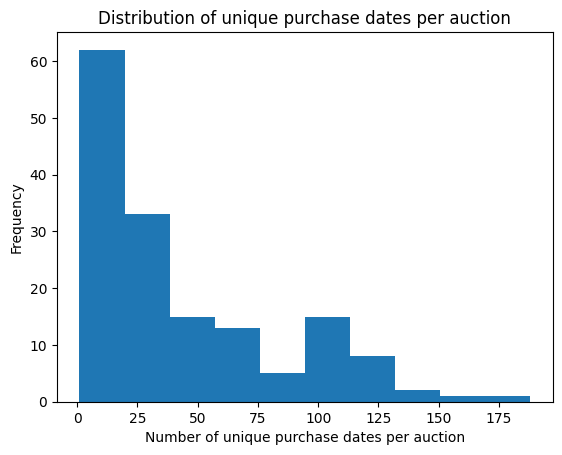

In [3]:
# Many auctions happen repeatedly
plt.hist(df["PurchDate"].groupby(df["Auction_VNZIP1"]).nunique().sort_values())
plt.xlabel("Number of unique purchase dates per auction")
plt.ylabel("Frequency")
plt.title("Distribution of unique purchase dates per auction")
plt.show()

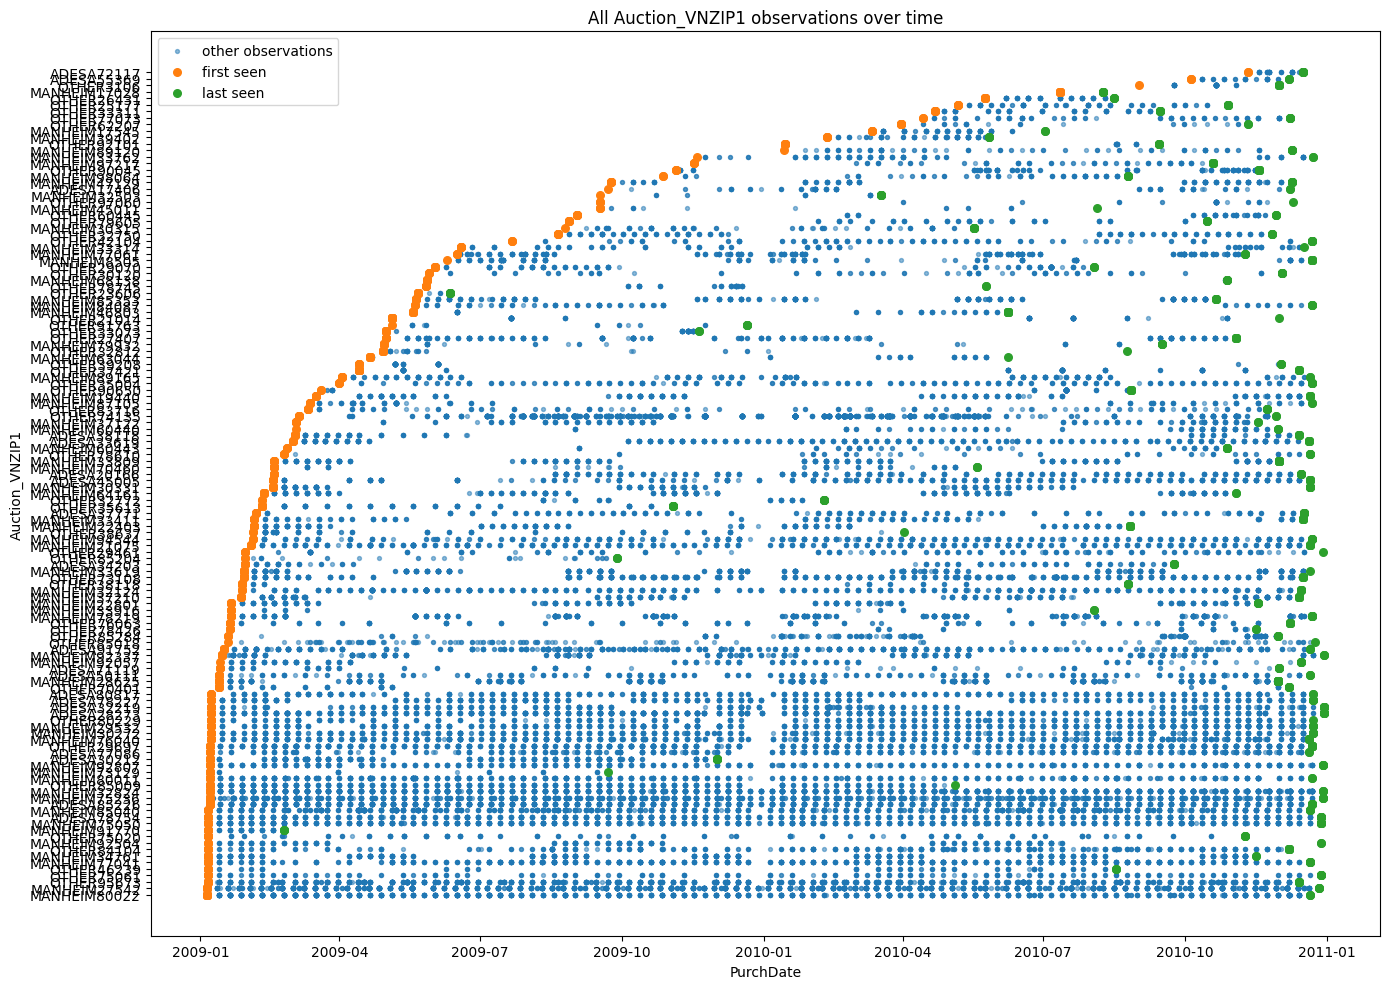

In [4]:
# Some auctions don't reappear over time, but most do.

tmp = df[["PurchDate", "Auction_VNZIP1"]].copy()
tmp["PurchDate"] = pd.to_datetime(tmp["PurchDate"])
tmp = tmp.dropna(subset=["PurchDate", "Auction_VNZIP1"])

# All observations as dots, with first/last colored differently
group_life = (
    tmp.groupby("Auction_VNZIP1")["PurchDate"]
       .agg(first_seen="min", last_seen="max", n_obs="size")
       .sort_values("first_seen")
)

# Optional: only show groups with enough rows
group_life_plot = group_life[group_life["n_obs"] >= 20].copy()
groups_to_plot = group_life_plot.index

# Keep only rows from plotted groups
plot_df = tmp[tmp["Auction_VNZIP1"].isin(groups_to_plot)].copy()

# Map each group to a y-position
y_map = {g: i for i, g in enumerate(groups_to_plot)}
plot_df["y"] = plot_df["Auction_VNZIP1"].map(y_map)

# Flag first/last rows within each group
plot_df["is_first"] = (
    plot_df["PurchDate"]
    == plot_df.groupby("Auction_VNZIP1")["PurchDate"].transform("min")
)
plot_df["is_last"] = (
    plot_df["PurchDate"]
    == plot_df.groupby("Auction_VNZIP1")["PurchDate"].transform("max")
)

# Middle points are everything that's neither first nor last
middle = plot_df[~plot_df["is_first"] & ~plot_df["is_last"]]
firsts = plot_df[plot_df["is_first"]]
lasts = plot_df[plot_df["is_last"]]

fig, ax = plt.subplots(figsize=(14, 10))

# All points
ax.scatter(
    middle["PurchDate"], middle["y"],
    s=8, alpha=0.5, label="other observations"
)

# First seen points
ax.scatter(
    firsts["PurchDate"], firsts["y"],
    s=30, label="first seen"
)

# Last seen points
ax.scatter(
    lasts["PurchDate"], lasts["y"],
    s=30, label="last seen"
)

ax.set_yticks(range(len(groups_to_plot)))
ax.set_yticklabels(groups_to_plot)
ax.set_title("All Auction_VNZIP1 observations over time")
ax.set_xlabel("PurchDate")
ax.set_ylabel("Auction_VNZIP1")
ax.legend()

plt.tight_layout()
plt.show()

In [5]:
# Proof that the original train/test split was not random, but based on "Auction" and "VNZIP1". 
intersection = set(df["Auction"].astype(str) + df["VNZIP1"].astype(str)).intersection(set(test["VNZIP1"].astype(str)))
union = set(df["Auction"].astype(str) + df["VNZIP1"].astype(str)).union(set(test["VNZIP1"].astype(str)))

len(intersection) / len(union)

0.0

In [6]:
# Use if needed to get see all cols of pandas dataframes
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
df.head()

,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost,Auction_VNZIP1
0,0,2009-12-07,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,RED,AUTO,1.0,Alloy,89046,OTHER ASIAN,MEDIUM,OTHER,8155.0,9829.0,11636.0,13600.0,7451.0,8552.0,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113,ADESA33619
1,0,2009-12-07,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,WHITE,AUTO,1.0,Alloy,93593,AMERICAN,LARGE TRUCK,CHRYSLER,6854.0,8383.0,10897.0,12572.0,7456.0,9222.0,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053,ADESA33619
2,0,2009-12-07,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,MAROON,AUTO,2.0,Covers,73807,AMERICAN,MEDIUM,CHRYSLER,3202.0,4760.0,6943.0,8457.0,4035.0,5557.0,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389,ADESA33619
3,0,2009-12-07,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,SILVER,AUTO,1.0,Alloy,65617,AMERICAN,COMPACT,CHRYSLER,1893.0,2675.0,4658.0,5690.0,1844.0,2646.0,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630,ADESA33619
4,0,2009-12-07,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,SILVER,MANUAL,2.0,Covers,69367,AMERICAN,COMPACT,FORD,3913.0,5054.0,7723.0,8707.0,3247.0,4384.0,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020,ADESA33619


In [7]:
df = df.drop(columns=["Auction_VNZIP1"])

## Data Checks

In [8]:
from data_foundry import dataset_checks
df_head, summary, numeric_stats, cat_stats, target_df = dataset_checks.run_all_checks(
    data=df,
    classification=task_mold.is_classification,
    target_feature=task_mold.target_column_name,
    print_report=False, # In notebook...
)


#### Dataset Overview
Rows: 72,983
Columns: 33
Use sampling: False (sample size: 72,983)
Get row duplicates (staged, merged)...
Using top-10 columns for initial filtering: ['VehOdo', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentRetailCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRCurrentRetailAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRCurrentAuctionCleanPrice', 'MMRAcquisitionAuctionAveragePrice', 'MMRCurrentAuctionAveragePrice', 'VehBCost']
Rows remaining as candidates after top-10 filter: 6 (of 72,983)

#### Duplicate Report
Total duplicate rows: 0 (0.00% of dataset)
Duplicate rows ignoring target: 0 (0.00% of dataset)
Get column duplicates...
Duplicate columns: 0 (0.00% of columns)

Data quality checks completed.


In [9]:
# Sample Rows
df_head

,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,0,2009-12-07,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,RED,AUTO,1.0,Alloy,89046,OTHER ASIAN,MEDIUM,OTHER,8155.0,9829.0,11636.0,13600.0,7451.0,8552.0,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,0,2009-12-07,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,WHITE,AUTO,1.0,Alloy,93593,AMERICAN,LARGE TRUCK,CHRYSLER,6854.0,8383.0,10897.0,12572.0,7456.0,9222.0,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,0,2009-12-07,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,MAROON,AUTO,2.0,Covers,73807,AMERICAN,MEDIUM,CHRYSLER,3202.0,4760.0,6943.0,8457.0,4035.0,5557.0,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,0,2009-12-07,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,SILVER,AUTO,1.0,Alloy,65617,AMERICAN,COMPACT,CHRYSLER,1893.0,2675.0,4658.0,5690.0,1844.0,2646.0,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,0,2009-12-07,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,SILVER,MANUAL,2.0,Covers,69367,AMERICAN,COMPACT,FORD,3913.0,5054.0,7723.0,8707.0,3247.0,4384.0,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020


In [10]:
# Feature Summary
summary

,index,dtype,n_missing,pct_missing,n_unique,examples
0,PRIMEUNIT,category,69564.0,95.32,2.0,"NO, YES"
1,AUCGUART,category,69564.0,95.32,2.0,"GREEN, RED"
2,WheelType,category,3174.0,4.35,3.0,"Alloy, Covers, Special"
3,WheelTypeID,category,3169.0,4.34,4.0,"1.0, 2.0, 3.0, 0.0"
4,Trim,category,2360.0,3.23,134.0,"Bas, LS, SE, SXT, LT, LX, Tou, EX, SEL, XLT"
5,SubModel,category,8.0,0.01,863.0,"4D SEDAN, 4D SEDAN LS, 4D SEDAN SE, 4D WAGON, MINIVAN 3.3L, 4D SUV 4.2L LS, 4D SEDAN LT, 4D SEDAN SXT FFV, 2D COUPE, 4D SEDAN LX"
6,Color,category,8.0,0.01,16.0,"SILVER, WHITE, BLUE, GREY, BLACK, RED, GOLD, GREEN, MAROON, BEIGE"
7,Transmission,category,9.0,0.01,3.0,"AUTO, MANUAL, Manual"
8,Nationality,category,5.0,0.01,4.0,"AMERICAN, OTHER ASIAN, TOP LINE ASIAN, OTHER"
9,Size,category,5.0,0.01,12.0,"MEDIUM, LARGE, MEDIUM SUV, COMPACT, VAN, LARGE TRUCK, SMALL SUV, SPECIALTY, CROSSOVER, LARGE SUV"


In [11]:
# Numeric Feature Statistics
numeric_stats

,count,mean,std,min,max
IsBadBuy,72983.0,0.122988,0.328425,0.0,1.0
VehYear,72983.0,2005.343052,1.731252,2001.0,2010.0
VehicleAge,72983.0,4.176644,1.712210,0.0,9.0
VehOdo,72983.0,71499.995917,14578.913128,4825.0,115717.0
MMRAcquisitionAuctionAveragePrice,72965.0,6128.909217,2461.992768,0.0,35722.0
MMRAcquisitionAuctionCleanPrice,72965.0,7373.636031,2722.491986,0.0,36859.0
MMRAcquisitionRetailAveragePrice,72965.0,8497.034332,3156.285284,0.0,39080.0
MMRAcquisitonRetailCleanPrice,72965.0,9850.928240,3385.789541,0.0,41482.0
MMRCurrentAuctionAveragePrice,72668.0,6132.081287,2434.567723,0.0,35722.0
MMRCurrentAuctionCleanPrice,72668.0,7390.681827,2686.248852,0.0,36859.0


In [12]:
# Categorical Feature Statistics
cat_stats

value  count    pct
column               rank                                    
AUCGUART             1                     <NA>  69564  95.32
                     2                    GREEN   3340   4.58
                     3                      RED     79   0.11
Auction              1                  MANHEIM  41043  56.24
                     2                    OTHER  17501  23.98
                     3                    ADESA  14439  19.78
BYRNO                1                    99761   3943   5.40
                     2                    18880   3588   4.92
                     3                      835   2987   4.09
                     4                     3453   2927   4.01
                     5                    22916   2852   3.91
Color                1                   SILVER  14875  20.38
                     2                    WHITE  12123  16.61
                     3                     BLUE  10347  14.18
                     4                     GREY   7887  10.81
                     5                    BLACK   7627  10.45
Make                 1                CHEVROLET  17248  23.63
                     2                    DODGE  12912  17.69
                     3                     FORD  11305  15.49
                     4                 CHRYSLER   8844  12.12
                     5                  PONTIAC   4258   5.83
Model                1               PT CRUISER   2329   3.19
                     2                   IMPALA   1990   2.73
                     3                   TAURUS   1425   1.95
                     4                  CALIBER   1375   1.88
                     5     CARAVAN GRAND FWD V6   1289   1.77
Nationality          1                 AMERICAN  61028  83.62
                     2              OTHER ASIAN   8033  11.01
                     3           TOP LINE ASIAN   3722   5.10
                     4                    OTHER    195   0.27
                     5                     <NA>      5   0.01
PRIMEUNIT            1                     <NA>  69564  95.32
                     2                       NO   3357   4.60
                     3                      YES     62   0.08
PurchDate            1      2010-11-23 00:00:00    384   0.53
                     2      2009-02-25 00:00:00    379   0.52
                     3      2010-12-08 00:00:00    372   0.51
                     4      2010-10-13 00:00:00    359   0.49
                     5      2009-08-26 00:00:00    359   0.49
Size                 1                   MEDIUM  30785  42.18
                     2                    LARGE   8850  12.13
                     3               MEDIUM SUV   8090  11.08
                     4                  COMPACT   7205   9.87
                     5                      VAN   5854   8.02
SubModel             1                 4D SEDAN  15236  20.88
                     2              4D SEDAN LS   4718   6.46
                     3              4D SEDAN SE   3859   5.29
                     4                 4D WAGON   2230   3.06
                     5             MINIVAN 3.3L   1258   1.72
TopThreeAmericanName 1                       GM  25314  34.68
                     2                 CHRYSLER  23399  32.06
                     3                     FORD  12315  16.87
                     4                    OTHER  11950  16.37
                     5                     <NA>      5   0.01
Transmission         1                     AUTO  70398  96.46
                     2                   MANUAL   2575   3.53
                     3                     <NA>      9   0.01
                     4                   Manual      1   0.00
Trim                 1                      Bas  13950  19.11
                     2                       LS  10174  13.94
                     3                       SE   9348  12.81
                     4                      SXT   3825   5.24
                     5                       LT   3540   4.85
VNST        

In [13]:
# Target Distribution
target_df

,count,pct
IsBadBuy,,
0,64007,87.7
1,8976,12.3


## Task Curation

In [14]:
from data_foundry.curation_recommendations import get_recommended_splits_dimensions

n_repeats, n_splits, none_or_test_size = get_recommended_splits_dimensions( # if the data was IID
    dataset=df,
)
print(f"Recommended splits: n_repeats={n_repeats}, n_splits={n_splits}, test_size={none_or_test_size}")

Recommended splits: n_repeats=3, n_splits=3, test_size=None


In [15]:
def get_recommended_temporal_splits(
    dates,
    train_n_dates,
    valid_n_dates,
    step_n_dates=None,
    gap_n_dates=0,
    expanding=True,
):
    dates = pd.to_datetime(pd.Series(dates)).reset_index(drop=True)

    if not dates.is_monotonic_increasing:
        raise ValueError("dates must be sorted ascending.")

    if step_n_dates is None:
        step_n_dates = valid_n_dates

    unique_dates = pd.Index(dates.unique())
    n_unique = len(unique_dates)

    collected = []

    if expanding:
        valid_start_pos = train_n_dates + gap_n_dates

        while True:
            valid_end_pos = valid_start_pos + valid_n_dates
            if valid_end_pos > n_unique:
                break

            train_end_pos = valid_start_pos - gap_n_dates

            train_dates = unique_dates[:train_end_pos]
            valid_dates = unique_dates[valid_start_pos:valid_end_pos]

            train_idx = dates.index[dates.isin(train_dates)].tolist()
            valid_idx = dates.index[dates.isin(valid_dates)].tolist()

            collected.append((train_idx, valid_idx))
            valid_start_pos += step_n_dates

    else:
        train_start_pos = 0

        while True:
            train_end_pos = train_start_pos + train_n_dates
            valid_start_pos = train_end_pos + gap_n_dates
            valid_end_pos = valid_start_pos + valid_n_dates

            if valid_end_pos > n_unique:
                break

            train_dates = unique_dates[train_start_pos:train_end_pos]
            valid_dates = unique_dates[valid_start_pos:valid_end_pos]

            train_idx = dates.index[dates.isin(train_dates)].tolist()
            valid_idx = dates.index[dates.isin(valid_dates)].tolist()

            collected.append((train_idx, valid_idx))
            train_start_pos += step_n_dates

    # Reverse so the split with the most train data comes first
    collected = collected[::-1]

    out = {}
    for repeat_id, (train_idx, valid_idx) in enumerate(collected):
        out[repeat_id] = {0: (train_idx, valid_idx)}

    return out

In [18]:
from data_foundry.schema import PredictiveMLSplitsMetadata

date_col = task_mold.time_on
target_col = task_mold.target_column_name

df = df.sort_values(by=date_col).reset_index(drop=True)

rec_splits = n_repeats*n_splits
n_unique_dates = df[date_col].nunique()
train_n_dates = int(n_unique_dates/2) # Use at least half of all available dates to prevent too small training sets biasing the evaluation.
valid_n_dates = int((n_unique_dates-train_n_dates) / rec_splits)

splits = get_recommended_temporal_splits(
    dates=df[date_col],
    train_n_dates=train_n_dates,
    valid_n_dates=valid_n_dates,
    step_n_dates=None,
    gap_n_dates=0,
    expanding=True,
)

used_in_train = set()
used_in_test = set()
used_data = set()

for split in splits:
    train_idx, test_idx = splits[split][0]

    # Diagnostics
    print(f"\n=== Step {split} ===")
    print("Train size:", len(train_idx), "| Test size:", len(test_idx))
    print("Train target mean:", df.loc[train_idx, target_col].mean())
    print("Test target mean:", df.loc[test_idx, target_col].mean())

    used_in_train.update(train_idx)
    used_in_test.update(test_idx)
    used_data.update(train_idx)
    used_data.update(test_idx)

    if split>0:
        assert set(splits[split-1][0][1]).isdisjoint(set(splits[split][0][1])), "Test indices in folds overlap!"

assert len(used_data) == len(used_in_train.union(used_in_test)), "Some data points are not used at all in the splits!"

print(f"{len(used_in_train)/df.shape[0]:4f} of the samples are used in training")
print(f"{len(used_in_test)/df.shape[0]:4f} of the samples are used in testing.")

splits_mold = PredictiveMLSplitsMetadata(
    splits_comment=f"We always use {valid_n_dates} days of the data as test data and all prior data as training data. Each split uses at least 50% of all dates for training. We create {rec_splits} splits.",
    splits=splits,
    time_horizon=28,
    time_horizon_unit="days",
)
print(valid_n_dates, rec_splits)


=== Step 0 ===
Train size: 68012 | Test size: 4701
Train target mean: 0.12178733164735635
Test target mean: 0.13614124654328866

=== Step 1 ===
Train size: 62684 | Test size: 5328
Train target mean: 0.12301384723374385
Test target mean: 0.10735735735735735

=== Step 2 ===
Train size: 59029 | Test size: 3655
Train target mean: 0.12205864913855902
Test target mean: 0.1384404924760602

=== Step 3 ===
Train size: 55114 | Test size: 3915
Train target mean: 0.1217113619044163
Test target mean: 0.1269476372924649

=== Step 4 ===
Train size: 51191 | Test size: 3923
Train target mean: 0.12240432888593698
Test target mean: 0.11266887586031099

=== Step 5 ===
Train size: 46916 | Test size: 4275
Train target mean: 0.12298576178702361
Test target mean: 0.1160233918128655

=== Step 6 ===
Train size: 43044 | Test size: 3872
Train target mean: 0.12117832915156584
Test target mean: 0.14307851239669422

=== Step 7 ===
Train size: 38964 | Test size: 4080
Train target mean: 0.11777538240427061
Test targe

## Export

In [19]:
from data_foundry.curation_container import CuratedContainer
curated_data = CuratedContainer(
    dataset=df,
    dataset_metadata=dataset_mold,
    task_metadata=task_mold,
    experiment_metadata=splits_mold,
 )
curated_data.save()
print(curated_data.uuid)
print(curated_data.checksum)

Calculating checksum for curated container...
Saving curated container to kick/019d309d-6946-7ce9-8855-d4eaa085cc8a
019d309d-6946-7ce9-8855-d4eaa085cc8a
6855078498d6f7a4d2d7c13fc075c0333def5a259859992322014403c62bec59
